<a href="https://colab.research.google.com/github/mszhdgr/Machine_learning/blob/Main/Multiclass%20Classification/Wine_quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import kagglehub

path = kagglehub.dataset_download("uciml/red-wine-quality-cortez-et-al-2009")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'red-wine-quality-cortez-et-al-2009' dataset.
Path to dataset files: /kaggle/input/red-wine-quality-cortez-et-al-2009


In [4]:
import pandas as pd

df = pd.read_csv("/kaggle/input/red-wine-quality-cortez-et-al-2009/winequality-red.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
df['quality'].unique()

array([5, 6, 7, 4, 8, 3])

In [6]:
len(df)

1599

In [7]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [8]:
df.isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [11]:
cols = []
[cols.append(col) for col in df.columns if col != 'quality']
cols

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol']

In [12]:
features = pd.DataFrame(df, columns=cols)
features.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 10))
scaled_features = scaler.fit_transform(features)

In [14]:
scaled_features

array([[2.47787611, 3.97260274, 0.        , ..., 6.06299213, 1.37724551,
        1.53846154],
       [2.83185841, 5.20547945, 0.        , ..., 3.62204724, 2.09580838,
        2.15384615],
       [2.83185841, 4.38356164, 0.4       , ..., 4.09448819, 1.91616766,
        2.15384615],
       ...,
       [1.50442478, 2.67123288, 1.3       , ..., 5.35433071, 2.51497006,
        4.        ],
       [1.15044248, 3.59589041, 1.2       , ..., 6.53543307, 2.2754491 ,
        2.76923077],
       [1.23893805, 1.30136986, 4.7       , ..., 5.11811024, 1.9760479 ,
        4.        ]])

In [15]:
scaled_features.shape

(1599, 11)

In [18]:
labels = df["quality"].values
labels

array([5, 5, 5, ..., 6, 5, 6])

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(scaled_features, labels)
len(X_train),len(X_test)

(1199, 400)

In [21]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [22]:
def train_model(model, xtrain, ytrain, xtest, ytest):
  model_fit = model.fit(xtrain, ytrain)
  pred = model.predict(xtest)
  cr = classification_report(ytest, pred)
  print(cr)
  cm = confusion_matrix(ytest, pred)
  print(cm)
  ConfusionMatrixDisplay(cm).plot()
  plt.show()

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        17
           5       0.58      0.76      0.66       155
           6       0.57      0.61      0.59       170
           7       0.71      0.24      0.36        50
           8       0.00      0.00      0.00         5

    accuracy                           0.58       400
   macro avg       0.31      0.27      0.27       400
weighted avg       0.56      0.58      0.55       400

[[  0   0   3   0   0   0]
 [  0   0  15   1   1   0]
 [  0   0 118  37   0   0]
 [  0   0  64 104   2   0]
 [  0   0   2  36  12   0]
 [  0   0   0   3   2   0]]


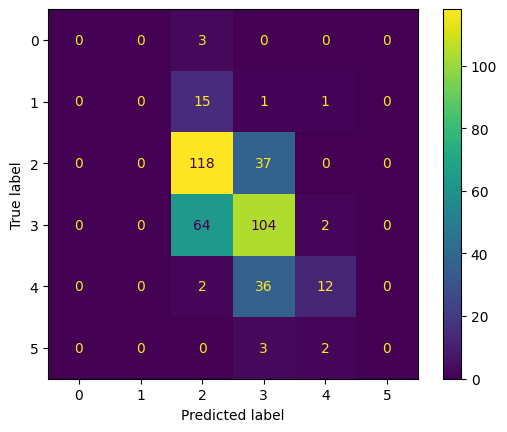

In [23]:
train_model(SVC(), X_train, y_train, X_test, y_test)

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.19      0.18      0.18        17
           5       0.63      0.72      0.67       155
           6       0.64      0.58      0.61       170
           7       0.48      0.52      0.50        50
           8       0.00      0.00      0.00         5

    accuracy                           0.59       400
   macro avg       0.32      0.33      0.33       400
weighted avg       0.59      0.59      0.59       400

[[  0   2   1   0   0   0]
 [  0   3  10   3   1   0]
 [  1   4 111  33   6   0]
 [  0   7  47  98  18   0]
 [  0   0   7  16  26   1]
 [  0   0   0   2   3   0]]


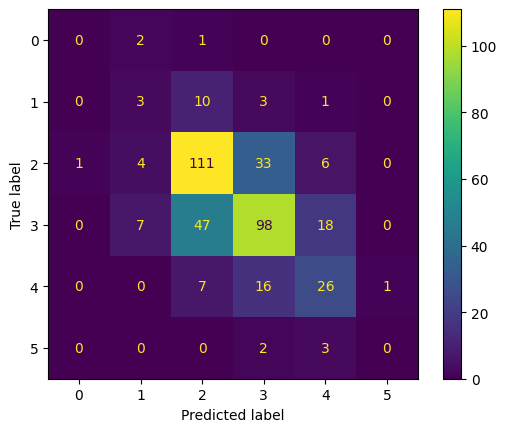

In [24]:
train_model(KNeighborsClassifier(n_neighbors=3), X_train, y_train, X_test, y_test)

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        17
           5       0.58      0.74      0.65       155
           6       0.54      0.49      0.52       170
           7       0.42      0.38      0.40        50
           8       0.00      0.00      0.00         5

    accuracy                           0.55       400
   macro avg       0.26      0.27      0.26       400
weighted avg       0.51      0.55      0.52       400

[[  0   1   2   0   0   0]
 [  0   0  12   4   1   0]
 [  0   1 115  35   4   0]
 [  0   0  68  84  18   0]
 [  0   0   1  30  19   0]
 [  0   0   0   2   3   0]]


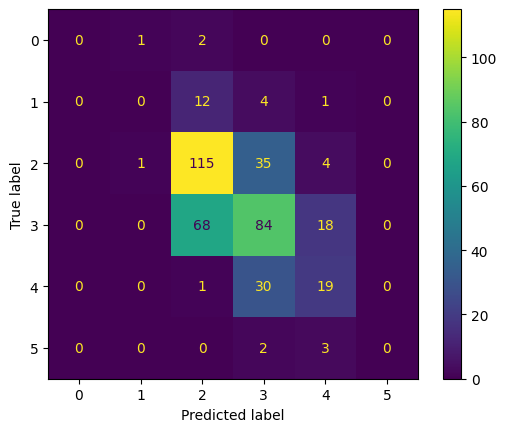

In [25]:
train_model(MultinomialNB(), X_train, y_train, X_test, y_test)